<a href="https://colab.research.google.com/github/Yuliana-Lestari/data-science-2026/blob/main/Pertemuan4_YulianaLestari_250401020199.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Data Science - Universitas Siber Asia

* **Nama Lengkap:** Yuliana Lestari

* **NIM:** 250401020199

* **Kelas:** IF403

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nTipe Data:')
print(df.dtypes)

print('\n5 Data Teratas:')
print(df.head())

print('\nStatistik Deskriptif:')
print(df.describe().round(3))

Shape: (150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

5 Data Teratas:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Statistik Deskriptif:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        

In [3]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]

    print(f'\n=== {col_name} ===')
    print(f'Mean     : {col.mean():.3f}')
    print(f'Median   : {col.median():.3f}')
    print(f'Std Dev  : {col.std():.3f}')
    print(f'Varians  : {col.var():.3f}')
    print(f'Skewness : {col.skew():.3f}')
    print(f'Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
Mean     : 5.843
Median   : 5.800
Std Dev  : 0.828
Varians  : 0.686
Skewness : 0.315
Kurtosis : -0.552

=== sepal_width ===
Mean     : 3.057
Median   : 3.000
Std Dev  : 0.436
Varians  : 0.190
Skewness : 0.319
Kurtosis : 0.228

=== petal_length ===
Mean     : 3.758
Median   : 4.350
Std Dev  : 1.765
Varians  : 3.116
Skewness : -0.275
Kurtosis : -1.402

=== petal_width ===
Mean     : 1.199
Median   : 1.300
Std Dev  : 0.762
Varians  : 0.581
Skewness : -0.103
Kurtosis : -1.341


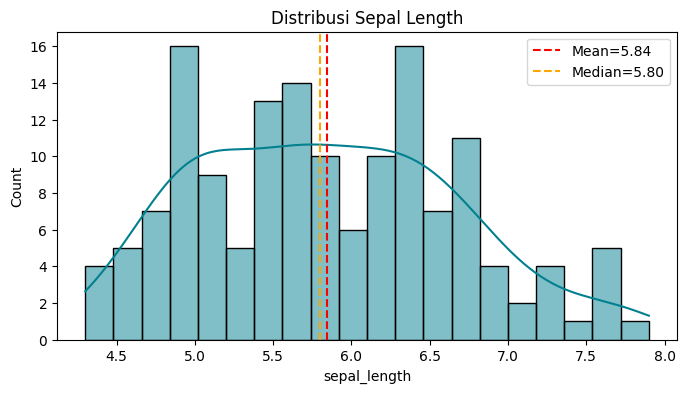

In [4]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median={df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()

Distribusi sepal_length cenderung mendekati distribusi normal karena nilai mean dan median hampir sama. Skewness bernilai kecil sehingga distribusi relatif simetris.

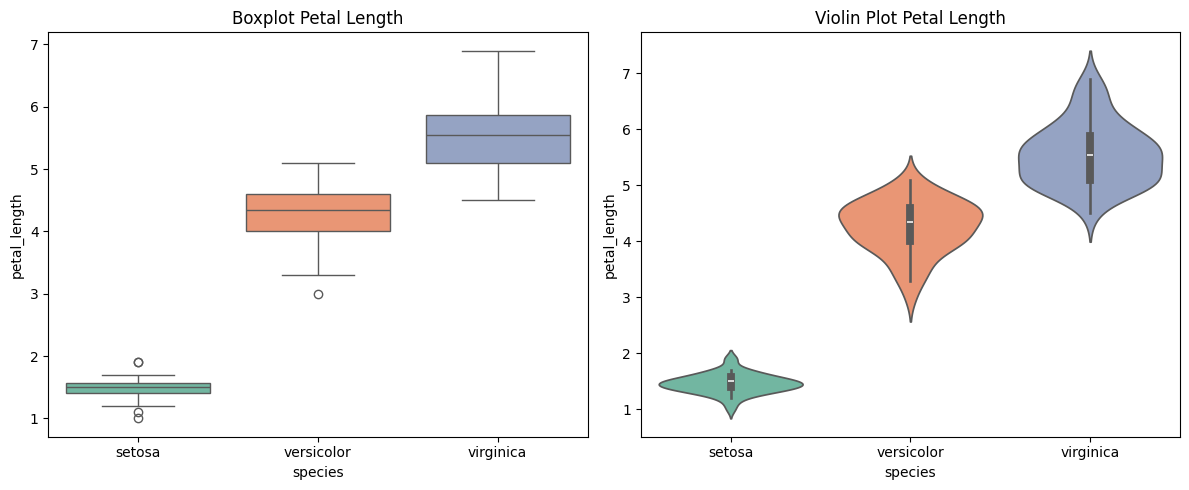

In [5]:
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

# Violin Plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

Spesies virginica memiliki petal_length terbesar, sedangkan setosa memiliki nilai terkecil. Virginica juga memiliki penyebaran data paling luas dibanding spesies lainnya.

In [6]:
corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))

import numpy as np

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(f'\nKorelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


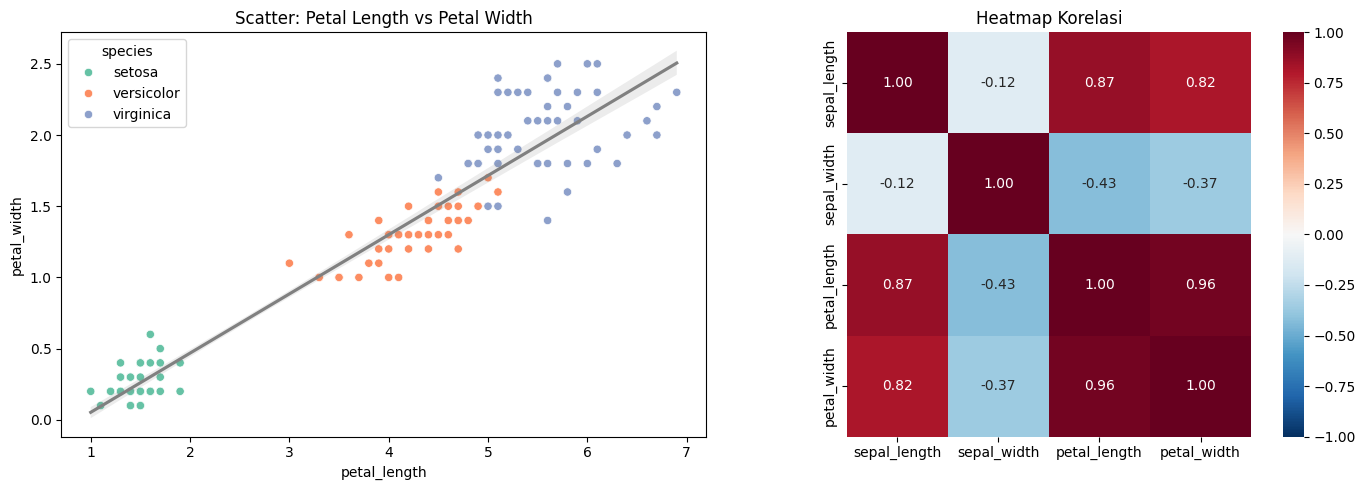

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Petal_length dan petal_width memiliki korelasi positif sangat kuat. Semakin panjang petal bunga, maka semakin lebar petalnya.

### Kesimpulan Praktikum (Pertemuan 4)

  Pada pertemuan ini, saya mempelajari fondasi statistika deskriptif (ukuran pemusatan dan penyebaran data) serta karakteristik distribusi data berdasarkan nilai skewness dan kurtosis. Selain itu, saya juga mempelajari teknik analisis univariat untuk memahami variabel tunggal, serta analisis bivariat untuk menguji hubungan antara dua variabel secara simultan.

  1. Median terbukti lebih tangguh (*robust*) terhadap gangguan nilai ekstrem (*outlier*) dibandingkan Mean, sedangkan nilai IQR (*Interquartile Range*) efektif digunakan sebagai acuan batas pemotongan outlier potensial (*IQR Fence*).
  2. Analisis univariat menggunakan visualisasi Histogram, KDE plot, Boxplot, dan Violin plot sangat informatif dalam memetakan bentuk sebaran, puncak densitas, serta ringkasan lima statistik utama data secara grafis.
  3. Analisis bivariat melalui koefisien Korelasi Pearson (untuk hubungan linear data normal) dan Spearman (untuk non-parametrik/rank) yang diperkuat visualisasi Heatmap memudahkan pencarian pola, arah, dan kekuatan hubungan antarfitur numerik secara cepat (seperti pada fitur kelopak dan mahkota bunga dataset Iris).

  Mengingat korelasi yang tinggi antara dua variabel tidak serta merta menunjukkan hubungan sebab-akibat (*correlation does not imply causation*), metode statistik dasar apa yang dapat diterapkan setelahnya untuk membuktikan apakah hubungan antarfitur tersebut bersifat kausalitas atau sekadar dipengaruhi oleh faktor ketiga (*confounding variable*)?